In [26]:
import os
import numpy as np
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from scipy.optimize import linear_sum_assignment

In [5]:
DATA_PATH = "../../data/output_data/"
FIGURES_PATH = "../../data/figures/"
dataset = "central_nervous_system_tumor"
pseudobulk = True
ncells = 1000
rd = 1
# Tools: BAMixChecker, CrossCheckFingerprints, HYSYS, NGSCheckmate, Vireo

In [6]:
def all_samples_matrix_viz(matrix_df, tool, dataset, save_fig=False):

    if pseudobulk:
        fig_name = f"pseudobulk_{dataset}_{tool}_rd{rd}_ncells{ncells}_all_samples_similarity_matrix"
    else:
        fig_name = f"{dataset}_{tool}_rd{rd}_all_samples_similarity_matrix"

    # Visualize ALL samples against ALL samples
    extreme_point = max(
        abs(matrix_df.min().min()), abs(matrix_df.max().max())
    )

    fig, ax = plt.subplots(figsize=(10, 10))
    if tool == "CrosscheckFingerprints":
        cmap = plt.get_cmap("RdBu")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(matrix_df, cmap=cmap, vmin= -extreme_point, vmax= extreme_point)
    else:
        cmap = plt.get_cmap("Oranges")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(matrix_df, cmap=cmap)

    ax.set_xticks(np.arange(len(matrix_df.columns)))
    ax.set_yticks(np.arange(len(matrix_df.index)))
    ax.set_xticklabels(matrix_df.columns, rotation=45, ha="left", fontdict={"fontsize": 10})
    ax.set_yticklabels(matrix_df.index, fontdict={"fontsize": 10})
    ax.xaxis.set_label_position("top")
    ax.set_title(f"{tool} Similarity Matrix", pad=20)

    fig.colorbar(cax, fraction=0.046, pad=0.04, shrink=0.5)

    if save_fig:
        fig.savefig(
            os.path.join(
                FIGURES_PATH, f"{fig_name}.png",
            ),
            bbox_inches="tight",
            dpi=300,
        )
        fig.savefig(
            os.path.join(
                FIGURES_PATH, f"{fig_name}.pdf",
            ),
            bbox_inches="tight",
            dpi=300,
        )

    return

In [281]:
def bulk_vs_singlecell_matrix_viz(matrix_df, tool, dataset, save_fig=False):

    if pseudobulk == True:
        fig_name = f"pseudobulk_{dataset}_{tool}_rd{rd}_ncells{ncells}_bulk_vs_singlecell_similarity_matrix"
    else:
        fig_name = f"{dataset}_{tool}_rd{rd}_bulk_vs_singlecell_similarity_matrix"

    # Visualize bulk against single-cell or single-nucleus samples
    sub_matrix = matrix_df[
        [col for col in matrix_df.columns if "single-cell" in col or "single-nucleus" in col]
    ]
    sub_matrix = sub_matrix.loc[
        [idx for idx in sub_matrix.index if "bulk" in idx]
    ]

    extreme_point = max(
        abs(sub_matrix.min().min()), abs(sub_matrix.max().max())
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    if tool == "CrosscheckFingerprints":
        cmap = plt.get_cmap("RdBu")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(sub_matrix, cmap=cmap, vmin= -extreme_point, vmax= extreme_point)
    else:
        cmap = plt.get_cmap("Oranges")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(sub_matrix, cmap=cmap)

    ax.set_xticks(np.arange(len(sub_matrix.columns)))
    ax.set_yticks(np.arange(len(sub_matrix.index)))
    ax.set_xticklabels(sub_matrix.columns, rotation=45, ha="left")
    ax.set_yticklabels(sub_matrix.index)
    ax.xaxis.set_label_position("top")
    ax.set_xlabel("Single-cell samples")
    ax.set_ylabel("Bulk samples")
    ax.set_title(f"{tool} Bulk vs Single-cell Similarity Matrix", pad=20)

    fig.colorbar(cax, fraction=0.046, pad=0.04, shrink=0.5)

    if save_fig:
        fig.savefig(
            os.path.join(
                FIGURES_PATH, f"{fig_name}.png",
            ),
            bbox_inches="tight",
            dpi=300,
        )
        fig.savefig(
            os.path.join(
                FIGURES_PATH, f"{fig_name}.pdf",
            ),
            bbox_inches="tight",
            dpi=300,
        )

    return

# Vireo

In [9]:
if pseudobulk:
    vireo_matrix = pd.read_csv(DATA_PATH + f"2a_vireo/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/similarity_matrix.csv", index_col=0)
else:
    vireo_matrix = pd.read_csv(DATA_PATH + f"2a_vireo/{dataset}/real_data/read_depth_{rd}/similarity_matrix.csv", index_col=0)

In [10]:
vireo_matrix.columns = [re.sub(r"[a-zA-Z0-9]{32}_", "", col.replace(".bam", "").replace("ds.", "")) for col in vireo_matrix.columns]
vireo_matrix.index = pd.Index([re.sub(r"[a-zA-Z0-9]{32}_", "", idx.replace(".bam", "").replace("ds.", "")) for idx in vireo_matrix.index])

In [11]:
# Order rows and columns
ordered_columns = sorted(vireo_matrix.columns)
ordered_index = sorted(vireo_matrix.index)
vireo_matrix = vireo_matrix.loc[ordered_index, ordered_columns]

In [12]:
vireo_matrix.head()

,GSM6467390_pseudobulk_GSM6467390_ncells_1000_1,GSM6467390_pseudobulk_GSM6467390_ncells_1000_2,GSM6467390_pseudobulk_GSM6467390_ncells_1000_3,GSM6467391_pseudobulk_GSM6467391_ncells_1000_1,GSM6467391_pseudobulk_GSM6467391_ncells_1000_2,GSM6467391_pseudobulk_GSM6467391_ncells_1000_3,GSM6467393_pseudobulk_GSM6467393_ncells_1000_1,GSM6467393_pseudobulk_GSM6467393_ncells_1000_2,GSM6467393_pseudobulk_GSM6467393_ncells_1000_3,GSM6467394_pseudobulk_GSM6467394_ncells_1000_1,...,GSM6467423_pseudobulk_GSM6467423_ncells_1000_3,GSM6467424_pseudobulk_GSM6467424_ncells_1000_1,GSM6467424_pseudobulk_GSM6467424_ncells_1000_2,GSM6467424_pseudobulk_GSM6467424_ncells_1000_3,GSM6467425_pseudobulk_GSM6467425_ncells_1000_1,GSM6467425_pseudobulk_GSM6467425_ncells_1000_2,GSM6467425_pseudobulk_GSM6467425_ncells_1000_3,GSM6467426_pseudobulk_GSM6467426_ncells_1000_1,GSM6467426_pseudobulk_GSM6467426_ncells_1000_2,GSM6467426_pseudobulk_GSM6467426_ncells_1000_3
GSM6467390_pseudobulk_GSM6467390_ncells_1000_1,0.000000,0.000444,0.000327,0.000583,0.001185,0.000483,0.000514,0.000409,0.000486,0.000525,...,0.000788,0.001492,0.000673,0.001103,0.003581,0.004750,0.001924,0.001040,0.001157,0.001563
GSM6467390_pseudobulk_GSM6467390_ncells_1000_2,0.000444,0.000000,0.000411,0.000662,0.001264,0.000567,0.000593,0.000488,0.000565,0.000609,...,0.000867,0.001579,0.000752,0.001182,0.003660,0.004837,0.002003,0.001119,0.001236,0.001642
GSM6467390_pseudobulk_GSM6467390_ncells_1000_3,0.000327,0.000411,0.000000,0.000528,0.001130,0.000433,0.000459,0.000354,0.000431,0.000461,...,0.000733,0.001431,0.000614,0.001048,0.003526,0.004703,0.001856,0.000977,0.001096,0.001508
GSM6467391_pseudobulk_GSM6467391_ncells_1000_1,0.000583,0.000662,0.000528,0.000000,0.001231,0.000605,0.000653,0.000560,0.000637,0.000685,...,0.000939,0.001630,0.000819,0.001250,0.003730,0.004909,0.002071,0.001190,0.001304,0.001714
GSM6467391_pseudobulk_GSM6467391_ncells_1000_2,0.001185,0.001264,0.001130,0.001231,0.000000,0.001138,0.001244,0.001140,0.001232,0.001287,...,0.001518,0.002226,0.001419,0.001832,0.004329,0.005515,0.002676,0.001786,0.001909,0.002298


In [13]:
vireo_matrix.shape

(90, 90)

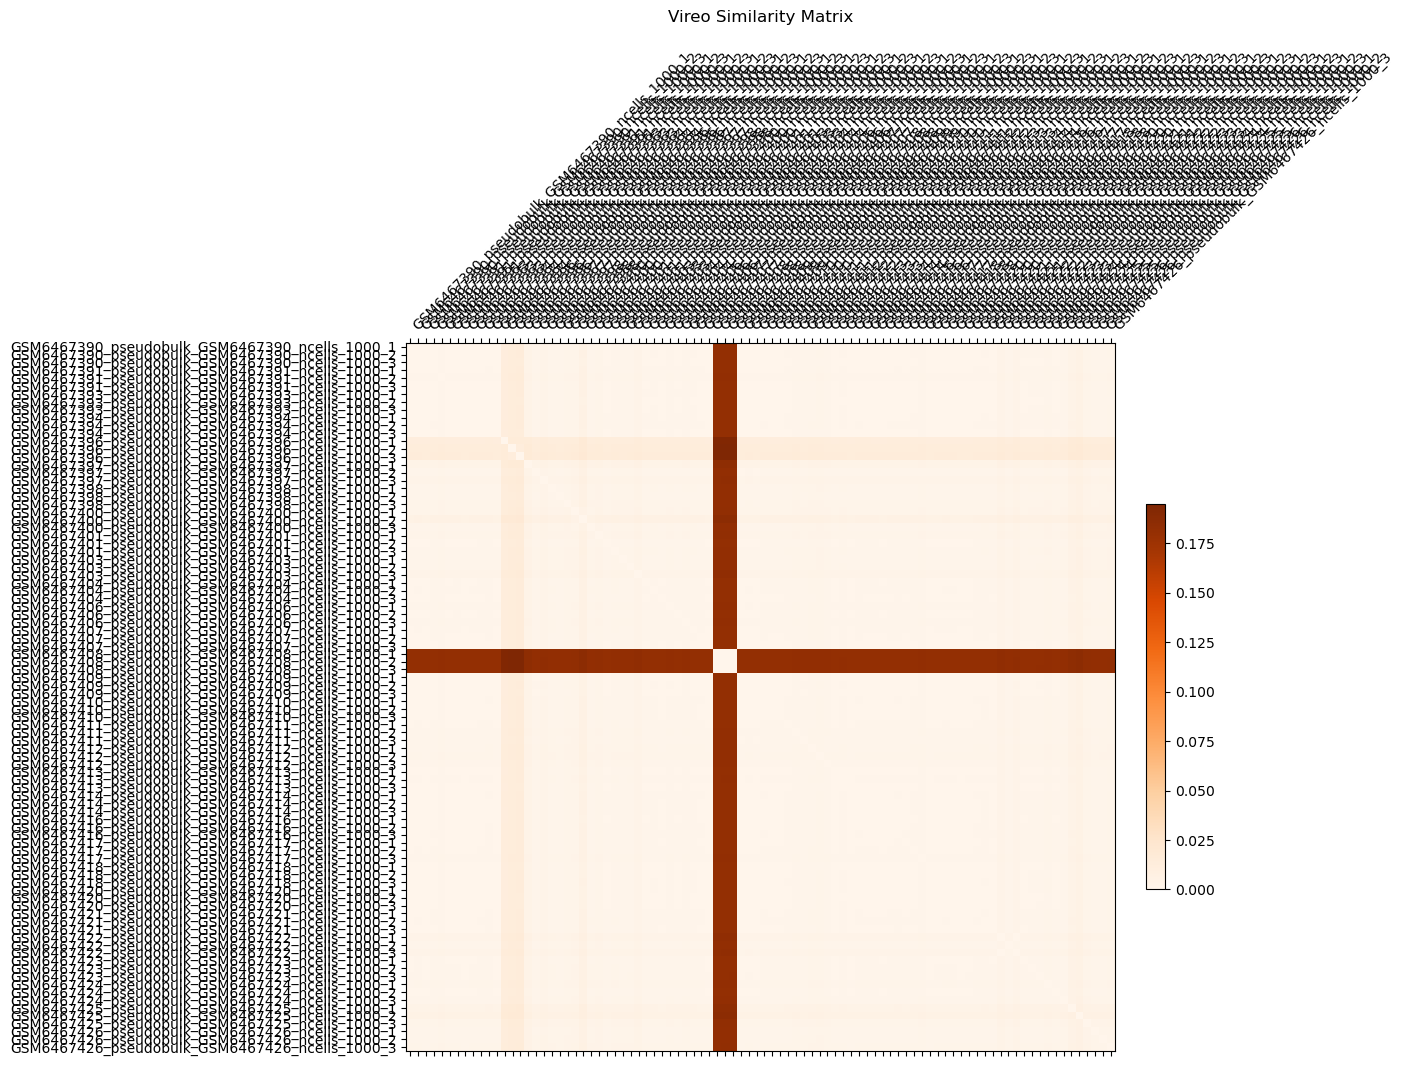

In [14]:
all_samples_matrix_viz(vireo_matrix, tool="Vireo", dataset=dataset, save_fig=True)

## Pseudobulk accuracy

In [60]:
if pseudobulk:
    vireo_matches = pd.read_csv(DATA_PATH + f"2a_vireo/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/matched_samples.csv", index_col=0).reset_index()
else:
    vireo_matches = pd.read_csv(DATA_PATH + f"2a_vireo/{dataset}/matched_samples.csv", index_col=0).reset_index()

In [61]:
for col in vireo_matches.columns:
    vireo_matches[col] = [re.sub(r"[a-zA-Z0-9]{32}_", "", sample.replace(".bam", "").replace("ds.", "")) for sample in vireo_matches[col]]

vireo_matches = vireo_matches.sort_values(by=["sample_id_0"]).reset_index(drop=True)

In [62]:
# How many correct matches?
correct_matches = vireo_matches[vireo_matches["sample_id_0"] == vireo_matches["sample_id_1"]]
print(f"Number of correct matches: {correct_matches.shape[0]} out of {vireo_matches.shape[0]}")

Number of correct matches: 90 out of 90


In [86]:
# Filter Vireo matrix to only samples ending in _1 in rows and samples ending in _2 in columns
vireo_matrix_filtered = vireo_matrix.loc[
    [idx for idx in vireo_matrix.index if idx.endswith("_2")],
    [col for col in vireo_matrix.columns if col.endswith("_3")]
]
# Remove sample with sample_id GSM6467408 in the name
# vireo_matrix_filtered = vireo_matrix_filtered.drop(
#     [idx for idx in vireo_matrix_filtered.index if "GSM6467408" in idx],
#     axis=0
# )
# vireo_matrix_filtered = vireo_matrix_filtered.drop(
#     [col for col in vireo_matrix_filtered.columns if "GSM6467408" in col],
#     axis=1
# )

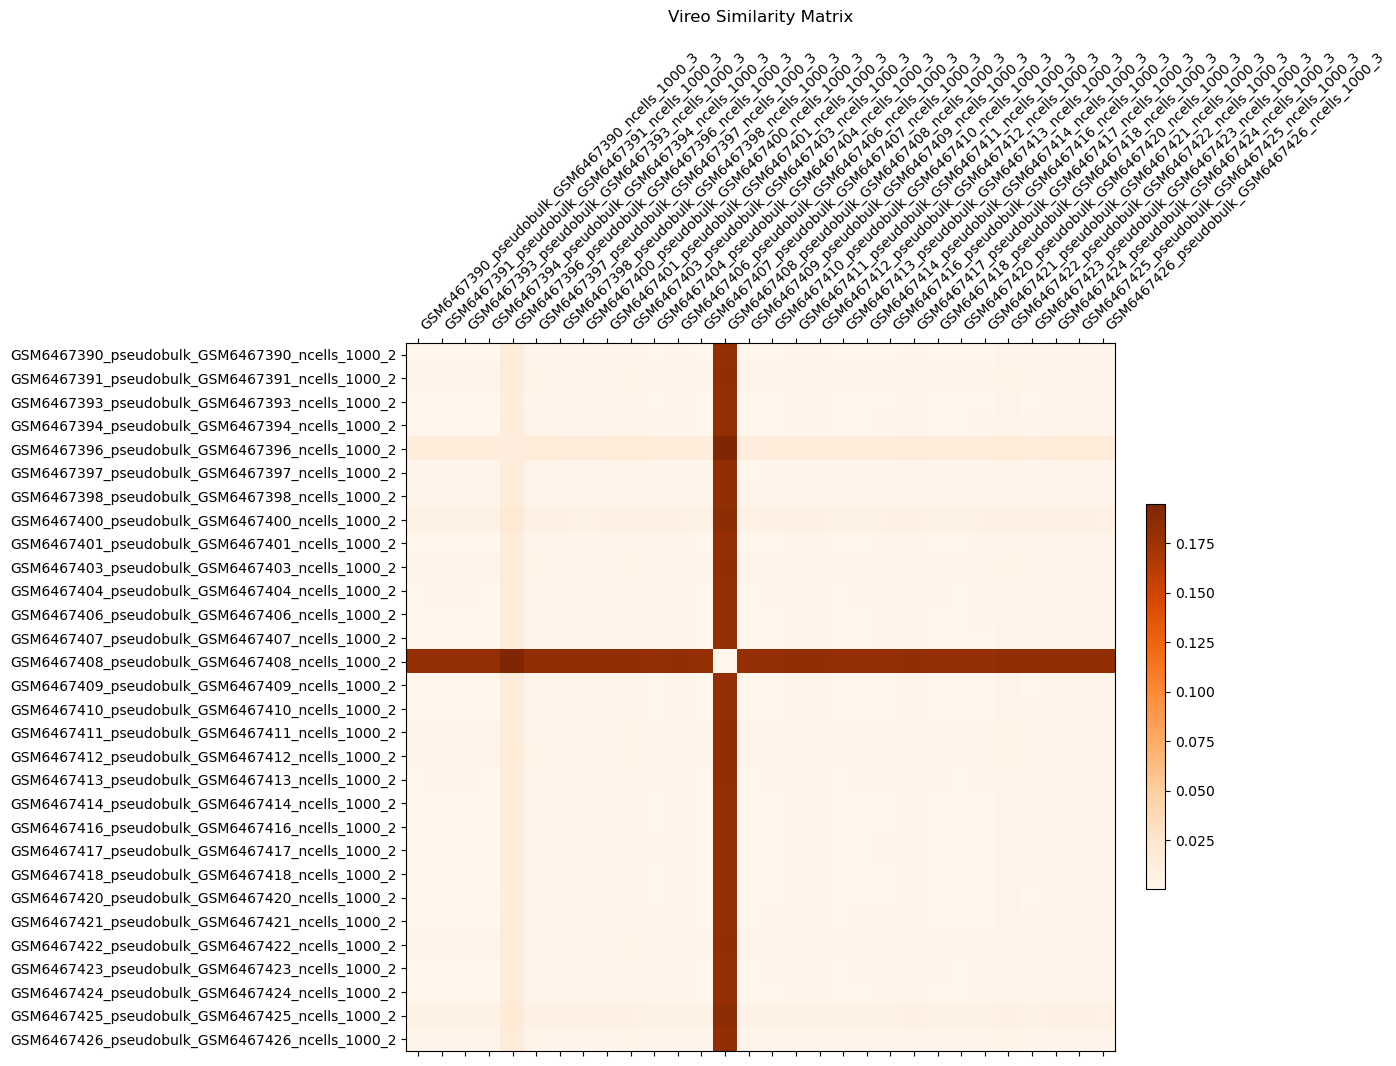

In [87]:
all_samples_matrix_viz(vireo_matrix_filtered, tool="Vireo", dataset=dataset, save_fig=True)

In [88]:
# Minimize diagonal of vireo_matrix_filtered by moving rows and columns around
idx0, idx1 = linear_sum_assignment(vireo_matrix_filtered.values)
vireo_matrix_reordered = pd.DataFrame(vireo_matrix_filtered.iloc[idx0, idx1], index=vireo_matrix_filtered.index[idx0], columns=vireo_matrix_filtered.columns[idx1])

In [89]:
# Check if the rows and columns have the same samples in the same order
vireo_matrix_reordered.index = [re.sub(r"_2$", "", idx) for idx in vireo_matrix_reordered.index]
vireo_matrix_reordered.columns = [re.sub(r"_3$", "", col) for col in vireo_matrix_reordered.columns]

In [ ]:
vireo_matches_reordered = pd.DataFrame({
    "sample_id_0": vireo_matrix_reordered.index,
    "sample_id_1": vireo_matrix_reordered.columns
})
# How many correct matches?
correct_matches = vireo_matches_reordered[vireo_matches_reordered["sample_id_0"] == vireo_matches_reordered["sample_id_1"]]
print(f"Number of correct matches: {correct_matches.shape[0]} out of {vireo_matches_reordered.shape[0]}")

In [ ]:
incorrect_matches = vireo_matches_reordered[vireo_matches_reordered["sample_id_0"] != vireo_matches_reordered["sample_id_1"]]
incorrect_matches

In [ ]:
vireo_matrix_reordered.head()

# NGSCheckmate

In [ ]:
ngscheckmate_df = pd.read_csv(DATA_PATH + f"ngscheckmate/{dataset}/output_all.txt", sep="\t", index_col=0, header=None)

In [ ]:
ngscheckmate_dict = {
    x: 
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace(".vcf", "").replace("ds.", "").replace("_individual_variants", ""))
    for x in list(set(ngscheckmate_df.index) | set(ngscheckmate_df[2]))
}
ngscheckmate_df.index = ngscheckmate_df.index.map(ngscheckmate_dict)
ngscheckmate_df[2] = ngscheckmate_df[2].map(ngscheckmate_dict)
ngscheckmate_df.columns = ["Matched", "Sample", "Binary", "Correlation"]

In [ ]:
ngscheckmate_df.head()

In [ ]:
def long_df_to_matrix_ngscheckmate(df):
    matrix = pd.DataFrame()

    for x in list(df.index):
        for y in df["Sample"].values:
            corr_value = df.loc[(df.index == x) & (df["Sample"] == y), "Correlation"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]/100
                matrix.at[x, y] = corr_value.values[0]/100

    # Order rows and columns by bulk modality and sample ID
    matrix = matrix.sort_index(
        key=lambda x: x.str.split('_').str[0]).sort_index(key=lambda x: x.str.split('_', n=1).str[1]
    )
    matrix = matrix.reindex(
        sorted(
            sorted(
                matrix.columns,
                key=lambda x: x.split('_', 1)[0]
            ),
            key=lambda x: x.split('_', 1)[1]
        )
    )
    matrix = matrix[matrix.index]

    return matrix

In [ ]:
ngscheckmate_matrix = long_df_to_matrix_ngscheckmate(ngscheckmate_df)

In [ ]:
ngscheckmate_matrix.head()

In [ ]:
# all_samples_matrix_viz(ngscheckmate_matrix, tool="NGSCheckmate", dataset=dataset, save_fig=True)

In [ ]:
bulk_vs_singlecell_matrix_viz(ngscheckmate_matrix, tool="NGSCheckmate", dataset=dataset, save_fig=True)

# HYSYS

In [ ]:
if pseudobulk:
    hysys_df = pd.read_csv(DATA_PATH + f"2a_hysys/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/concordance_output.txt", sep="\t", index_col=0, header=None)
else:
    hysys_df = pd.read_csv(DATA_PATH + f"2a_hysys/{dataset}/real_data/ncells_null/read_depth_{rd}/concordance_output.txt", sep="\t", index_col=0, header=None)

In [ ]:
hysys_dict = {
    x: 
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace(".bam", "").replace(f"{dataset}/", "").replace("_individual_variants.snps", "").replace("pseudobulk/", "").replace("real_data/", "").replace(f"ncells_{ncells}/", "").replace(f"read_depth_{rd}/", ""))
    # x.replace("_filtered_variants.snps", "").replace(f"{dataset}/", "")
    for x in list(set(hysys_df.index) | set(hysys_df[1]))
}
hysys_df.index = hysys_df.index.map(hysys_dict)
hysys_df[1] = hysys_df[1].map(hysys_dict)
hysys_df.columns = ["Sample", "Concordance", "Size"]

In [ ]:
hysys_df.head()

In [ ]:
def long_df_to_matrix_hysys(df):
    # Use pivot_table for much faster matrix creation
    df_reset = df.reset_index()
    matrix = df_reset.pivot_table(
        index=df_reset.columns[0],  # Use the first column (original index)
        columns='Sample', 
        values='Concordance',
        aggfunc='first'  # Use first value if duplicates exist
    )
    
    # Get all unique samples to create a square matrix
    all_samples = sorted(set(df.index) | set(df['Sample']))
    matrix = matrix.reindex(index=all_samples, columns=all_samples)
    
    # Order rows and columns by bulk modality and sample ID
    matrix = matrix.sort_index(key=lambda x: x.str.split('_').str[0]).sort_index(key=lambda x: x.str.split('_', n=1).str[1])
    matrix = matrix.reindex(
        sorted(
            sorted(
                matrix.columns,
                key=lambda x: x.split('_', 1)[0]
            ),
            key=lambda x: x.split('_', 1)[1]
        )
    )
    matrix = matrix[matrix.index]

    return matrix

In [ ]:
hysys_matrix = long_df_to_matrix_hysys(hysys_df)

In [ ]:
hysys_matrix.head()

In [ ]:
all_samples_matrix_viz(hysys_matrix, tool="HYSYS", dataset=dataset, save_fig=True)

## Pseudobulk accuracy

In [ ]:
if pseudobulk:
    hysys_matches = pd.read_csv(DATA_PATH + f"2a_hysys/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/model_results.txt", sep=",", skiprows=9, header=None)
else:
    hysys_matches = pd.read_csv(DATA_PATH + f"2a_hysys/{dataset}/real_data/ncells_null/read_depth_{rd}/model_results.txt", sep=",", skiprows=9, header=None)

In [ ]:
# Clean up hysys_matches to extract sample IDs from filepaths
hysys_matches.columns = ["Sample_1", "Sample_2", "Status"]
hysys_matches["Sample_1"] = hysys_matches["Sample_1"].str.replace(r".*/(.*?)\.snps", r"\1", regex=True)
hysys_matches["Sample_2"] = hysys_matches["Sample_2"].str.replace(r".*/(.*?)\.snps", r"\1", regex=True)

# Apply the same regex cleanup as other tools
for col in ["Sample_1", "Sample_2"]:
    hysys_matches[col] = [re.sub(r"[a-zA-Z0-9]{32}_", "", sample.replace("_individual_variants", "").replace("ds.", "")) for sample in hysys_matches[col]]

hysys_matches.head()

In [ ]:
# Filter HYSYS matrix to only samples ending in _1 in rows and samples ending in _2 in columns
hysys_matrix_filtered = hysys_matrix.loc[
    [idx for idx in hysys_matrix.index if idx.endswith("_2")],
    [col for col in hysys_matrix.columns if col.endswith("_3")]
]

In [ ]:
all_samples_matrix_viz(hysys_matrix_filtered, tool="HYSYS", dataset=dataset, save_fig=True)

# CrossCheckFingerprints

In [263]:
if pseudobulk:
    fingerprints_df = pd.read_csv(DATA_PATH + f"2a_fingerprints/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/crosscheck_metrics.txt", sep="\t", skiprows=6, header=0)
else:
    fingerprints_df = pd.read_csv(DATA_PATH + f"2a_fingerprints/{dataset}/real_data/ncells_null/read_depth_{rd}/crosscheck_metrics.txt", sep="\t", skiprows=6, header=0)
fingerprints_df = fingerprints_df[["LEFT_SAMPLE", "RIGHT_SAMPLE", "LOD_SCORE", "RESULT"]]

In [264]:
fingerprints_dict = {
    x: 
    # x.replace(".bam", "")
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace(".bam", "").replace("ds.", ""))
    
    for x in list(set(fingerprints_df["LEFT_SAMPLE"]) | set(fingerprints_df["RIGHT_SAMPLE"]))
}
fingerprints_df["LEFT_SAMPLE"] = fingerprints_df["LEFT_SAMPLE"].map(fingerprints_dict)
fingerprints_df["RIGHT_SAMPLE"] = fingerprints_df["RIGHT_SAMPLE"].map(fingerprints_dict)

In [265]:
fingerprints_df.head()

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
0,GSM7728224_bulk,GSM7728224_bulk,208.813253,EXPECTED_MATCH
1,GSM7728224_bulk,GSM6467400_single-nucleus,0.000000,INCONCLUSIVE
2,GSM7728224_bulk,GSM7728211_bulk,0.488336,UNEXPECTED_MATCH
3,GSM7728224_bulk,GSM7728199_bulk,1.001768,UNEXPECTED_MATCH
4,GSM7728224_bulk,GSM6467424_single-nucleus,0.000000,INCONCLUSIVE


In [266]:
def long_df_to_matrix_fingerprints(df):
    # Use pivot_table for much faster matrix creation
    matrix = df.pivot_table(
        index='LEFT_SAMPLE',
        columns='RIGHT_SAMPLE', 
        values='LOD_SCORE',
        aggfunc='first'  # Use first value if duplicates exist
    )
    
    # Get all unique samples to create a square matrix
    all_samples = sorted(set(df['LEFT_SAMPLE']) | set(df['RIGHT_SAMPLE']))
    matrix = matrix.reindex(index=all_samples, columns=all_samples)
    
    # Order rows and columns by bulk modality and sample ID
    matrix = matrix.sort_index(key=lambda x: x.str.split('_').str[0]).sort_index(key=lambda x: x.str.split('_', n=1).str[1])
    matrix = matrix.reindex(
        sorted(
            sorted(
                matrix.columns,
                key=lambda x: x.split('_', 1)[0]
            ),
            key=lambda x: x.split('_', 1)[1]
        )
    )
    matrix = matrix[matrix.index]

    return matrix

In [267]:
fingerprints_matrix = long_df_to_matrix_fingerprints(fingerprints_df)

In [273]:
fingerprints_matrix.head()

RIGHT_SAMPLE,GSM7728196_bulk,GSM7728197_bulk,GSM7728198_bulk,GSM7728199_bulk,GSM7728200_bulk,GSM7728201_bulk,GSM7728202_bulk,GSM7728203_bulk,GSM7728204_bulk,GSM7728205_bulk,...,GSM6467416_single-nucleus,GSM6467417_single-nucleus,GSM6467418_single-nucleus,GSM6467420_single-nucleus,GSM6467421_single-nucleus,GSM6467422_single-nucleus,GSM6467423_single-nucleus,GSM6467424_single-nucleus,GSM6467425_single-nucleus,GSM6467426_single-nucleus
LEFT_SAMPLE,,,,,,,,,,,,,,,,,,,,,
GSM7728196_bulk,322.824089,-2.660449,-3.371700,-4.379054,1.963932,-7.253828,-1.928718,-1.915852,-7.523734,1.139675,...,0.86762,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.174102,0.236221
GSM7728197_bulk,-2.660449,81.127696,12.870482,3.271336,5.215314,1.761234,0.484357,-0.027494,-2.921388,-0.792847,...,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.203148,0.122864
GSM7728198_bulk,-3.371700,12.870482,275.681973,4.572055,14.088099,-1.459479,4.158447,2.263543,-9.116789,5.605051,...,0.00000,1.125235,0.0,0.0,0.0,0.0,0.0,0.213494,0.204757,2.840971
GSM7728199_bulk,-4.379054,3.271336,4.572055,98.647460,2.789612,5.429690,1.158504,6.989539,-1.032195,-0.531742,...,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,-1.538571,0.546203
GSM7728200_bulk,1.963932,5.215314,14.088099,2.789612,116.699222,-7.979827,2.464287,-2.011510,-2.250053,-3.066194,...,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,-0.204391,0.204757,0.542176


In [302]:
fingerprints_matrix.shape

(65, 65)

In [269]:
# all_samples_matrix_viz(fingerprints_matrix, tool="CrosscheckFingerprints", dataset=dataset, save_fig=True)

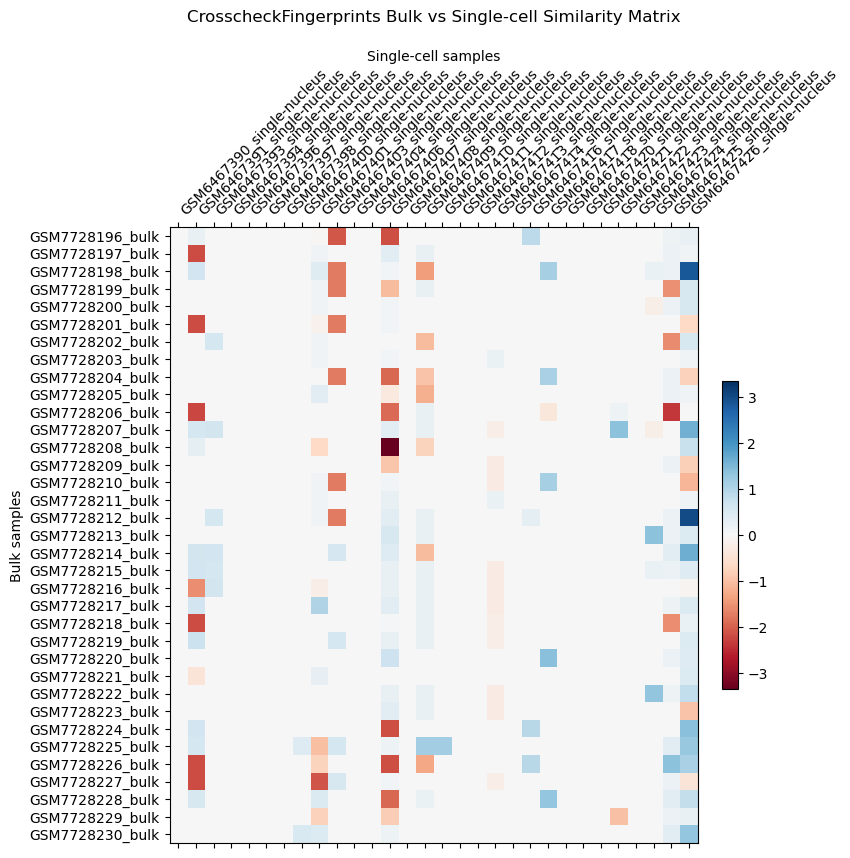

In [282]:
bulk_vs_singlecell_matrix_viz(fingerprints_matrix, tool="CrosscheckFingerprints", dataset=dataset, save_fig=True)

In [287]:
fingerprints_df.head()

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
0,GSM7728224_bulk,GSM7728224_bulk,208.813253,EXPECTED_MATCH
1,GSM7728224_bulk,GSM6467400_single-nucleus,0.000000,INCONCLUSIVE
2,GSM7728224_bulk,GSM7728211_bulk,0.488336,UNEXPECTED_MATCH
3,GSM7728224_bulk,GSM7728199_bulk,1.001768,UNEXPECTED_MATCH
4,GSM7728224_bulk,GSM6467424_single-nucleus,0.000000,INCONCLUSIVE


In [283]:
fingerprints_df["RESULT"].value_counts()

RESULT
INCONCLUSIVE         2526
UNEXPECTED_MATCH      938
EXPECTED_MISMATCH     702
EXPECTED_MATCH         59
Name: count, dtype: int64

In [284]:
# Confirmed that the expected matches are simply the samples matching themselves
fingerprint_exp_matches = fingerprints_df[fingerprints_df["RESULT"]=="EXPECTED_MATCH"]
fingerprint_exp_matches[fingerprint_exp_matches["LEFT_SAMPLE"] != fingerprint_exp_matches["RIGHT_SAMPLE"]]

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT


In [299]:
fingerprints_matches = fingerprints_df[fingerprints_df["RESULT"]=="UNEXPECTED_MATCH"]

In [300]:
fingerprints_matches

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
2,GSM7728224_bulk,GSM7728211_bulk,0.488336,UNEXPECTED_MATCH
3,GSM7728224_bulk,GSM7728199_bulk,1.001768,UNEXPECTED_MATCH
5,GSM7728224_bulk,GSM7728228_bulk,12.964267,UNEXPECTED_MATCH
6,GSM7728224_bulk,GSM7728215_bulk,5.980782,UNEXPECTED_MATCH
9,GSM7728224_bulk,GSM7728209_bulk,3.466308,UNEXPECTED_MATCH
...,...,...,...,...
4185,GSM6467391_single-nucleus,GSM7728217_bulk,0.639012,UNEXPECTED_MATCH
4201,GSM6467391_single-nucleus,GSM6467416_single-nucleus,1.296723,UNEXPECTED_MATCH
4204,GSM6467391_single-nucleus,GSM7728207_bulk,0.584754,UNEXPECTED_MATCH
4209,GSM6467391_single-nucleus,GSM7728225_bulk,0.584754,UNEXPECTED_MATCH


In [ ]:
# HGSOC
# Out of 80 unexpected matches
# There should be really only 40 pairs since it's symmetric
#
# 5/40 are polyA vs polyA (and they all involve sample 2507)
# 0 are ribo vs ribo
# 35/40 are polyA vs ribo

# CNST
# Out of 938 unexpected matches
# 
# 317/469 are bulk vs bulk
# 10/469 are sn vs sn
fingerprints_matches[
    ~(fingerprints_matches["LEFT_SAMPLE"].str.contains("bulk") & fingerprints_matches["RIGHT_SAMPLE"].str.contains("bulk")) &
    ~(fingerprints_matches["LEFT_SAMPLE"].str.contains("nucleus") & fingerprints_matches["RIGHT_SAMPLE"].str.contains("nucleus"))
].sort_values(
    by=["LEFT_SAMPLE", "RIGHT_SAMPLE"]
).drop_duplicates(
    "LOD_SCORE"
).reset_index(
    drop=True
)

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
0,GSM6467391_single-nucleus,GSM7728196_bulk,0.256326,UNEXPECTED_MATCH
1,GSM6467391_single-nucleus,GSM7728198_bulk,0.639012,UNEXPECTED_MATCH
2,GSM6467391_single-nucleus,GSM7728207_bulk,0.584754,UNEXPECTED_MATCH
3,GSM6467391_single-nucleus,GSM7728208_bulk,0.301517,UNEXPECTED_MATCH
4,GSM6467391_single-nucleus,GSM7728214_bulk,0.611853,UNEXPECTED_MATCH
...,...,...,...,...
92,GSM6467426_single-nucleus,GSM7728225_bulk,1.271786,UNEXPECTED_MATCH
93,GSM6467426_single-nucleus,GSM7728226_bulk,1.088415,UNEXPECTED_MATCH
94,GSM6467426_single-nucleus,GSM7728228_bulk,0.809076,UNEXPECTED_MATCH
95,GSM6467426_single-nucleus,GSM7728229_bulk,0.247261,UNEXPECTED_MATCH


# BAMixChecker

In [ ]:
bamixchecker_df = pd.read_csv(DATA_PATH + f"bamixchecker/{dataset}/BAMixChecker/Total_result.txt", sep="\t", index_col=0, header=None)
bamixchecker_df.columns = ["Sample", "Concordance Rate", "Conclusion"]

In [ ]:
bamixchecker_dict = {
    x: 
    # x.replace("_filtered_rg.bam", "") 
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace("_filtered_rg.bam", "").replace(f"{dataset}/", "").replace("_filtered_variants.snps", "").replace("ds.", ""))
    for x in list(set(bamixchecker_df.index) | set(bamixchecker_df["Sample"]))
}
bamixchecker_df.index = bamixchecker_df.index.map(bamixchecker_dict)
bamixchecker_df["Sample"] = bamixchecker_df["Sample"].map(bamixchecker_dict)

In [ ]:
bamixchecker_df.head()

In [ ]:
def long_df_to_matrix_bamixchecker(df):
    matrix = pd.DataFrame()

    for x in list(df.index):
        for y in df["Sample"].values:
            corr_value = df.loc[(df.index == x) & (df["Sample"] == y), "Concordance Rate"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]
                matrix.at[x, y] = corr_value.values[0]

    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [ ]:
bamixchecker_matrix = long_df_to_matrix_bamixchecker(bamixchecker_df)

In [ ]:
bamixchecker_matrix.head()

In [ ]:
# all_samples_matrix_viz(bamixchecker_matrix, tool="BAMixChecker", dataset=dataset, save_fig=True)

In [ ]:
bulk_vs_singlecell_matrix_viz(bamixchecker_matrix, tool="BAMixChecker", dataset=dataset, save_fig=True)

# Tool comparison

In [ ]:
venn2(subsets=(28, 28, 8), set_labels=('BAMixChecker \nCrosscheckFingerprints \nHYSYS \nVireo ', 'NGSCheckmate'))
plt.title("Agreement between tools")
# plt.savefig(FIGURES_PATH + f"{dataset}_tool_agreement_venn_diagram.png", bbox_inches="tight", dpi=300)
# plt.savefig(FIGURES_PATH + f"{dataset}_tool_agreement_venn_diagram.pdf", bbox_inches="tight", dpi=300